# IN6227 Assignment 1 (Variant 1): Decision Tree vs. k-Nearest Neighbors

This notebook compares a decision tree and a k-Nearest Neighbors (KNN) classifier on the provided binary classification dataset. It follows a complete data mining workflow:

1. Data understanding
2. Exploratory data analysis (EDA)
3. Data cleaning and feature selection / engineering
4. Model-specific preprocessing
5. Hyperparameter tuning with stratified 5-fold cross-validation
6. Evaluation on the test set

**How to run:** place `train.csv` and `test.csv` in a folder named `dataset/` next to this notebook, then run all cells. All random processes use `RANDOM_STATE = 42`.

## 0. Setup

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay, PrecisionRecallDisplay)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42      # fixed seed for reproducibility (an experimental setting, not a hyperparameter)
DATA_DIR = "dataset"   # folder containing train.csv and test.csv
FIG_DIR = "figures"    # all plots and the results table are saved here
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.width", 160)

In [2]:
# Optional, Google Colab only: upload the two CSV files if they are not present yet.
# When running locally, this cell does nothing as long as dataset/ contains both files.
if not all(os.path.exists(os.path.join(DATA_DIR, f)) for f in ["train.csv", "test.csv"]):
    try:
        import shutil
        from google.colab import files
        os.makedirs(DATA_DIR, exist_ok=True)
        for name in files.upload():          # select train.csv and test.csv together
            shutil.move(name, os.path.join(DATA_DIR, name))
    except ImportError:
        raise FileNotFoundError("Place train.csv and test.csv in the 'dataset/' folder.")
print(sorted(os.listdir(DATA_DIR)))

['test.csv', 'train.csv']


## 1. Data understanding

In [3]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
print("train:", train.shape, " test:", test.shape)

TARGET = "label"
NUM_COLS = train.drop(columns=[TARGET]).select_dtypes(include="number").columns.tolist()
CAT_COLS = [c for c in train.columns if c not in NUM_COLS + [TARGET]]
print("Numeric attributes:    ", NUM_COLS)
print("Categorical attributes:", CAT_COLS)
train.head()

train: (31112, 16)  test: (13334, 16)
Numeric attributes:     ['aptitude_score', 'performance_score', 'stability_index', 'load_ratio', 'index_weight', 'activity_duration', 'composite_rank']
Categorical attributes: ['geological_era', 'weather_pattern', 'region', 'personal_interest', 'brew_preference', 'instrument', 'species', 'mineral_type']


,geological_era,weather_pattern,region,aptitude_score,performance_score,stability_index,personal_interest,load_ratio,brew_preference,instrument,species,index_weight,mineral_type,activity_duration,composite_rank,label
0,Triassic,Heatwave,Texas,325.58,34.95,1.503,Foraging,23.878,Espresso,Dulcimer,Lynx,8.63,Marble,77.98,2.093,no
1,Triassic,Monsoon,Texas,333.63,256.50,3.283,Falconry,28.617,Espresso,Cello,Bison,14.22,Opal,95.76,3.028,no
2,Triassic,Monsoon,Texas,503.96,385.00,3.676,Astronomy,22.582,Espresso,Cello,Lynx,11.04,Diamond,114.03,4.564,yes
3,Triassic,Heatwave,Texas,404.61,156.44,2.812,Calligraphy,28.002,Latte,Oboe,Lynx,15.64,Sapphire,113.58,3.053,no
4,Triassic,Heatwave,Texas,358.89,144.05,2.735,Beekeeping,22.062,Espresso,Oboe,Lynx,10.99,Granite,79.40,2.730,no


The dataset has 8 categorical and 7 numeric attributes. The attribute names are anonymised, so every decision below is based on evidence from the data rather than domain knowledge. All categorical attributes are treated as **nominal** (no inherent order); `brew_preference` is binary.

In [4]:
# 1.1 Class distribution, missing values and duplicate data
print("Train labels:", train[TARGET].value_counts(dropna=False).to_dict())
print("Test labels: ", test[TARGET].value_counts(dropna=False).to_dict())
print("\nMissing values per attribute (train):")
print(train.isna().sum()[train.isna().sum() > 0])
feat_tr, feat_te = train.drop(columns=[TARGET]), test.drop(columns=[TARGET])
print("\nRecords with a missing label:     train =", train[TARGET].isna().sum(), ", test =", test[TARGET].isna().sum())
print("Records with missing attribute(s): train =", feat_tr.isna().any(axis=1).sum(), ", test =", feat_te.isna().any(axis=1).sum())
print("Duplicate records:                 train =", train.duplicated().sum(), ", test =", test.duplicated().sum())

Train labels: {'no': 23645, 'yes': 7464, nan: 3}
Test labels:  {'no': 10165, 'yes': 3168, nan: 1}

Missing values per attribute (train):
geological_era       2
weather_pattern      3
region               4
aptitude_score       4
performance_score    2
stability_index      2
personal_interest    6
load_ratio           2
brew_preference      7
instrument           3
species              3
index_weight         3
mineral_type         3
activity_duration    2
composite_rank       1
label                3
dtype: int64

Records with a missing label:     train = 3 , test = 1
Records with missing attribute(s): train = 47 , test = 20
Duplicate records:                 train = 0 , test = 0


About 24% of the records are labelled "yes" (moderate class imbalance). Predicting "no" for every record would already give about 76% accuracy, so accuracy is not used as the main metric; F-measure (F1) and the area under the precision–recall curve (AUPRC) are used instead, and all cross-validation folds are stratified. A few labels are missing, and missing attribute values are scattered across columns. No duplicate records were found.

In [5]:
# 1.2 Categorical attributes: number of values, rare values, "Unknown"/"Other" values
for c in CAT_COLS:
    vc = train[c].value_counts()
    print(f"{c:18s} values={train[c].nunique():2d}  smallest={vc.min():5d}  "
          f"values<100={int((vc < 100).sum()):2d}  "
          f"Unknown/Other={[v for v in vc.index if v in ('Unknown', 'Other')]}")

geological_era     values= 5  smallest=  252  values<100= 0  Unknown/Other=[]
weather_pattern    values= 7  smallest=   24  values<100= 1  Unknown/Other=[]
region             values=21  smallest=   49  values<100=13  Unknown/Other=['Other']
personal_interest  values=11  smallest= 1344  values<100= 0  Unknown/Other=['Other', 'Unknown']
brew_preference    values= 2  smallest=10328  values<100= 0  Unknown/Other=[]
instrument         values= 6  smallest=  964  values<100= 0  Unknown/Other=[]
species            values= 7  smallest=  919  values<100= 0  Unknown/Other=['Unknown', 'Other']
mineral_type       values=16  smallest=   47  values<100= 1  Unknown/Other=[]


In [6]:
# 1.3 Do the two "Unknown" values occur in the same records, and how does their label distribution compare?
u_pi = train["personal_interest"] == "Unknown"
u_sp = train["species"] == "Unknown"
print("Both Unknown:", (u_pi & u_sp).sum(), "| only personal_interest:", (u_pi & ~u_sp).sum(),
      "| only species:", (~u_pi & u_sp).sum())
print("'yes' rate where both are Unknown:", round((train.loc[u_pi & u_sp, TARGET] == "yes").mean(), 3),
      " vs. overall:", round((train[TARGET] == "yes").mean(), 3))

Both Unknown: 1760 | only personal_interest: 7 | only species: 0
'yes' rate where both are Unknown: 0.087  vs. overall: 0.24


`personal_interest` and `species` both contain "Unknown" (and "Other"); `region` contains "Other". The two "Unknown" values occur in almost the same 1,760 records, whose "yes" rate (8.7%) is far below the overall 24%. The missingness is therefore not random and carries information about the label, so "Unknown" is kept as a separate category instead of being imputed with the mode. `region` is dominated by Texas (about 90%), and several values are rare.

In [7]:
# 1.4 Numeric attributes: summary statistics, zeros, skewness and share of values beyond 1.5 x IQR
desc = train[NUM_COLS].describe().T
desc["zeros"] = (train[NUM_COLS] == 0).sum()
desc["skew"] = train[NUM_COLS].skew()
q1, q3 = train[NUM_COLS].quantile(0.25), train[NUM_COLS].quantile(0.75)
iqr = q3 - q1
desc["beyond_1.5IQR_%"] = (((train[NUM_COLS] < q1 - 1.5 * iqr) | (train[NUM_COLS] > q3 + 1.5 * iqr)).mean() * 100).round(1)
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,zeros,skew,beyond_1.5IQR_%
aptitude_score,31108.0,342.134,68.925,90.000,310.598,333.515,402.562,510.000,0,-0.292,2.0
performance_score,31110.0,296.493,187.620,0.000,146.572,275.385,420.170,1010.000,265,0.552,0.5
stability_index,31110.0,3.156,0.849,0.000,2.751,3.351,3.762,4.625,265,-1.229,3.6
load_ratio,31110.0,24.423,9.920,0.000,19.272,23.689,27.657,143.717,38,1.705,8.1
index_weight,31109.0,12.722,7.747,0.000,7.520,11.730,16.230,99.620,4,1.511,3.3
activity_duration,31110.0,80.361,25.515,0.000,72.740,80.330,90.258,205.000,38,0.199,17.2
composite_rank,31111.0,3.239,0.870,0.589,2.591,3.199,3.838,6.876,0,0.258,0.4


In [8]:
# 1.5 Paired zeros: are they the same records, and what are their labels?
z_ps = (train["performance_score"] == 0) & (train["stability_index"] == 0)
z_la = (train["load_ratio"] == 0) & (train["activity_duration"] == 0)
print("performance_score = 0:", (train["performance_score"] == 0).sum(), "records, of which stability_index = 0:", z_ps.sum())
print("  labels of these records:", train.loc[z_ps, TARGET].value_counts().to_dict())
print("load_ratio = 0 and activity_duration = 0:", z_la.sum(), "records, labels:", train.loc[z_la, TARGET].value_counts().to_dict())
t_ps = (test["performance_score"] == 0) & (test["stability_index"] == 0)
print("Paired zeros in the test set:", t_ps.sum(), "records, labels:", test.loc[t_ps, TARGET].value_counts().to_dict())

performance_score = 0: 265 records, of which stability_index = 0: 265
  labels of these records: {'no': 265}
load_ratio = 0 and activity_duration = 0: 38 records, labels: {'no': 32, 'yes': 6}
Paired zeros in the test set: 122 records, labels: {'no': 122}


`performance_score` and `stability_index` are both zero in the same 265 training records, all labelled "no" (likewise for the 122 such test records). These zeros could be placeholders for missing values or a genuine pattern. Because the task is to predict the label and the pattern is strongly associated with it, the values are kept and a `perf_zero` indicator is added (feature creation); imputing them would erase a real signal.

## 2. Exploratory data analysis

In [9]:
# 2.1 Is composite_rank derived from other attributes? Check with a linear regression.
d = train.dropna(subset=NUM_COLS)
others = [c for c in NUM_COLS if c != "composite_rank"]
lr = LinearRegression().fit(d[others], d["composite_rank"])
print("R^2 =", round(lr.score(d[others], d["composite_rank"]), 6))
print(dict(zip(others, lr.coef_.round(5))))

R^2 = 1.0
{'aptitude_score': np.float64(0.006), 'performance_score': np.float64(0.004), 'stability_index': np.float64(-0.0), 'load_ratio': np.float64(-0.0), 'index_weight': np.float64(0.0), 'activity_duration': np.float64(0.0)}


`composite_rank` ≈ 0.006 × `aptitude_score` + 0.004 × `performance_score` (R² ≈ 1.000). It is a **redundant feature**: it adds no new information and is removed.

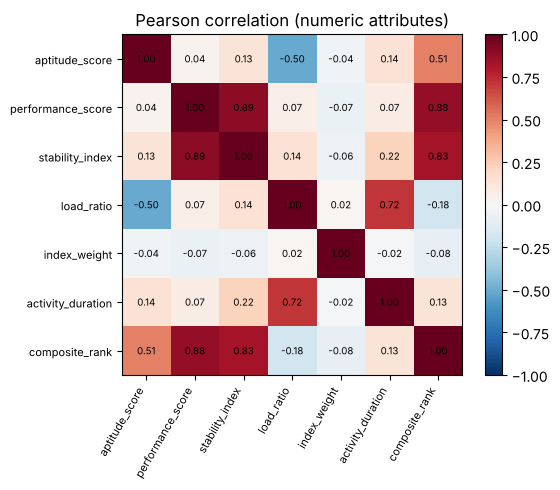

Correlation with the label: {'aptitude_score': 0.329, 'performance_score': 0.226, 'stability_index': 0.27, 'load_ratio': -0.003, 'index_weight': -0.008, 'activity_duration': 0.227, 'composite_rank': 0.352}


In [10]:
# 2.2 Correlation heatmap of numeric attributes and their correlation with the label
y_bin = (train[TARGET] == "yes").astype(float)
corr = train[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(NUM_COLS))); ax.set_xticklabels(NUM_COLS, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(NUM_COLS))); ax.set_yticklabels(NUM_COLS, fontsize=8)
for i in range(len(NUM_COLS)):
    for j in range(len(NUM_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, fraction=0.046); ax.set_title("Pearson correlation (numeric attributes)")
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/corr_heatmap.png", dpi=200); plt.show()
print("Correlation with the label:", train[NUM_COLS].corrwith(y_bin).round(3).to_dict())

In [11]:
# 2.3 Does a near-zero correlation mean an attribute is irrelevant?
#     "yes" rate in ten equal-frequency bins (deciles), to detect non-linear relationships
for c in ["load_ratio", "index_weight"]:
    rate = train.groupby(pd.qcut(train[c], 10, duplicates="drop"), observed=True)[TARGET] \
                .apply(lambda s: (s == "yes").mean()).round(2)
    print(c, rate.tolist())

load_ratio [0.1, 0.28, 0.31, 0.3, 0.25, 0.24, 0.24, 0.25, 0.26, 0.18]
index_weight [0.21, 0.25, 0.25, 0.26, 0.25, 0.26, 0.23, 0.22, 0.23, 0.23]


`load_ratio` has a near-zero correlation with the label, but its "yes" rate first rises and then falls across the deciles: a non-linear relationship that correlation cannot detect, so it is kept. The "yes" rate of `index_weight` is nearly flat, which suggests an **irrelevant feature**; this is checked with a wrapper approach in Section 7.

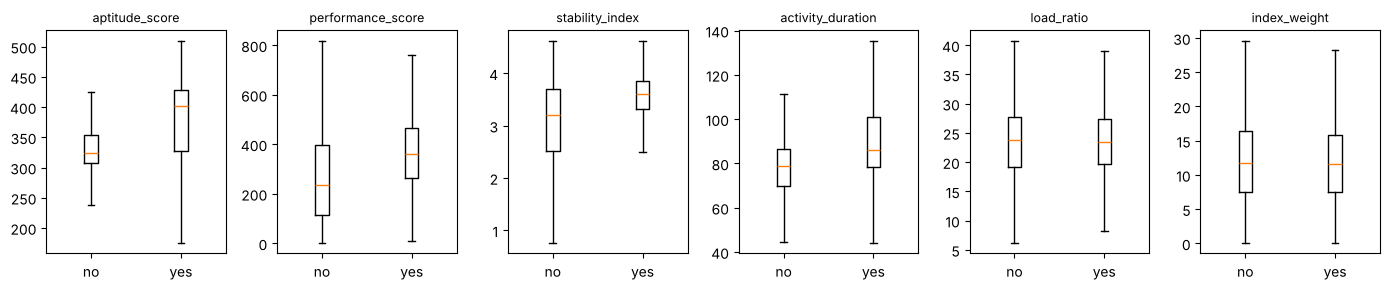

In [12]:
# 2.4 Box plots of numeric attributes by label (whiskers at 1.5 x IQR, outliers hidden)
show = ["aptitude_score", "performance_score", "stability_index", "activity_duration", "load_ratio", "index_weight"]
fig, axes = plt.subplots(1, len(show), figsize=(14, 3))
for ax, c in zip(axes, show):
    data = [train.loc[train[TARGET] == k, c].dropna() for k in ["no", "yes"]]
    ax.boxplot(data, whis=1.5, showfliers=False)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["no", "yes"])
    ax.set_title(c, fontsize=9)
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/boxplots_by_label.png", dpi=200); plt.show()

In [13]:
# 2.5 Categorical attributes: range of the "yes" rate across values (discriminative power)
for c in CAT_COLS:
    rate = train.groupby(c)[TARGET].apply(lambda s: (s == "yes").mean()).sort_values()
    print(f"{c:18s} 'yes' rate from {rate.min():.2f} to {rate.max():.2f}")

geological_era     'yes' rate from 0.11 to 0.26
weather_pattern    'yes' rate from 0.04 to 0.45
region             'yes' rate from 0.02 to 0.39
personal_interest  'yes' rate from 0.04 to 0.48
brew_preference    'yes' rate from 0.11 to 0.30
instrument         'yes' rate from 0.01 to 0.47
species            'yes' rate from 0.09 to 0.56
mineral_type       'yes' rate from 0.02 to 0.75


`instrument`, `weather_pattern`, `mineral_type` and `personal_interest` separate the classes well; `region` and `geological_era` much less. This is later compared with the decision tree's feature importance.

In [14]:
# 2.6 Are some categorical attributes redundant with other attributes?
def correlation_ratio(cat, num):
    # eta squared: share of the numeric attribute's variance explained by the categories
    d = train[[cat, num]].dropna(); g = d.groupby(cat)[num]; m = d[num].mean()
    return (g.size() * (g.mean() - m) ** 2).sum() / ((d[num] - m) ** 2).sum()

def cramers_v(a, b):
    # association between two categorical attributes (0 = none, 1 = perfect)
    t = pd.crosstab(train[a], train[b]).values; n = t.sum(); e = np.outer(t.sum(1), t.sum(0)) / n
    return np.sqrt(((t - e) ** 2 / e).sum() / (n * (min(t.shape) - 1)))

print("mineral_type vs. aptitude_score: eta^2 =", round(correlation_ratio("mineral_type", "aptitude_score"), 3))
print(train.groupby("mineral_type")["aptitude_score"].agg(["mean", "std"]).round(1).sort_values("mean").T)
print("instrument vs. weather_pattern: Cramer's V =", round(cramers_v("instrument", "weather_pattern"), 2))

mineral_type vs. aptitude_score: eta^2 = 0.987
mineral_type  Chalk  Flint  Slate  Shale  Basalt  Obsidian   Onyx  Jasper  Marble   Opal  Granite  Quartz  Sapphire   Ruby  Emerald  Diamond
mean          101.3  127.5  153.5  180.2   206.5     233.5  260.2   286.1   313.2  340.0    366.5   393.0     420.0  446.8    472.8    499.2
std             8.9    7.0    7.6    7.8     7.8       8.1    7.9     7.4     7.8    8.0      7.9     8.3       8.0    8.1      8.1      7.4
instrument vs. weather_pattern: Cramer's V = 0.49


`mineral_type` explains about 99% of the variance of `aptitude_score`: each value corresponds to a narrow band of `aptitude_score`, so the two attributes carry almost the same information. `instrument` is also moderately associated with `weather_pattern`. These relationships help interpret the decision tree's feature importance in Section 6.

## 3. Data cleaning and feature selection / engineering

| Issue | Action | Rationale |
|---|---|---|
| Missing labels | Drop records | Cannot be used for training or evaluation |
| Scattered missing values | Median (numeric) / mode (categorical) imputation, fitted on training data only | The median is robust to skew and outliers; every test record is kept |
| "Unknown" / "Other" | Keep as separate categories | Missingness is not random and carries information |
| Paired zeros | Keep, plus a `perf_zero` indicator | Strongly associated with the label |
| `composite_rank` | Remove | Redundant feature (R² ≈ 1) |
| `load_ratio` | Keep | Non-linear relationship with the label |
| Rare values (< 100 records) | Aggregate into "Rare" | Too few records for reliable estimates; reduces overfitting |
| Skew / outliers | Keep; log transformation + standardization for KNN only | The share beyond 1.5 × IQR reflects the distribution's shape; trees split on thresholds |
| Class imbalance | Stratified CV; F1 and AUPRC; class weighting tried during tuning | Accuracy is misleading |

In [15]:
# 3.1 Drop records without a label; encode the label as 0/1 ("yes" = 1, the positive class)
train = train.dropna(subset=[TARGET]).reset_index(drop=True)
test  = test.dropna(subset=[TARGET]).reset_index(drop=True)
y_train = (train[TARGET] == "yes").astype(int)
y_test  = (test[TARGET] == "yes").astype(int)
X_train = train.drop(columns=[TARGET])
X_test  = test.drop(columns=[TARGET])

# 3.2 Feature creation: indicator for the paired-zero records
for X in (X_train, X_test):
    X["perf_zero"] = (X["performance_score"] == 0).astype(int)

# 3.3 Remove the redundant feature
DROP = ["composite_rank"]
X_train = X_train.drop(columns=DROP)
X_test  = X_test.drop(columns=DROP)

# 3.4 Aggregate rare values into "Rare" (threshold based on training counts only)
RARE_MIN = 100
for c in CAT_COLS:
    counts = X_train[c].value_counts()
    rare = counts[counts < RARE_MIN].index
    X_train[c] = X_train[c].where(~X_train[c].isin(rare), "Rare")
    X_test[c]  = X_test[c].where(~X_test[c].isin(rare), "Rare")
    if len(rare): print(f"{c}: aggregated into 'Rare' -> {list(rare)}")

num_feats = [c for c in NUM_COLS if c not in DROP] + ["perf_zero"]
cat_feats = CAT_COLS
print("Final attributes:", len(num_feats), "numeric +", len(cat_feats), "categorical")
print("Baseline test accuracy (predict 'no' for every record):", round(1 - y_test.mean(), 4))

weather_pattern: aggregated into 'Rare' -> ['Typhoon']
region: aggregated into 'Rare' -> ['Rhode-Island', 'Wisconsin', 'Nevada', 'Idaho', 'Connecticut', 'Tennessee', 'Georgia', 'Virginia', 'Arkansas', 'Iowa', 'Missouri', 'West-Virginia', 'Nebraska']
mineral_type: aggregated into 'Rare' -> ['Chalk']
Final attributes: 7 numeric + 8 categorical
Baseline test accuracy (predict 'no' for every record): 0.7624


## 4. Model-specific preprocessing

| | Decision tree | KNN |
|---|---|---|
| Missing values | Median / mode imputation | Same |
| Categorical attributes | One-hot encoding (nominal attributes) | One-hot encoding (required: nominal values cannot be used in a distance) |
| Scaling | Not needed (splits on thresholds) | Standardization (z-score), so no attribute dominates the distance |
| Skewed attributes | Not transformed | Log transformation (`log1p`) of `load_ratio` and `index_weight` |

All steps are placed in a scikit-learn `Pipeline`, so imputation, encoding and scaling are fitted only on the training part of each cross-validation fold (no information leakage).

In [16]:
def make_preprocessor(model_type):
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    if model_type == "tree":
        num_pipe = Pipeline([("impute", SimpleImputer(strategy="median"))])
        return ColumnTransformer([("num", num_pipe, num_feats), ("cat", cat_pipe, cat_feats)])
    # KNN: log transformation for skewed attributes, then standardization of all numeric attributes
    skewed = ["load_ratio", "index_weight"]
    other_num = [c for c in num_feats if c not in skewed]
    log_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("log", FunctionTransformer(np.log1p)),
                         ("scale", StandardScaler())])
    num_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    return ColumnTransformer([("log", log_pipe, skewed), ("num", num_pipe, other_num), ("cat", cat_pipe, cat_feats)])

tree_pipe = Pipeline([("prep", make_preprocessor("tree")),
                      ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))])
knn_pipe  = Pipeline([("prep", make_preprocessor("knn")),
                      ("clf", KNeighborsClassifier())])

n_dim = make_preprocessor("knn").fit(X_train).transform(X_train.head()).shape[1]
print("Dimensions after one-hot encoding:", n_dim)

Dimensions after one-hot encoding: 70


## 5. Hyperparameter tuning

Grid search with stratified 5-fold cross-validation on the training set (each fold keeps the same proportion of "yes" records). F1 is the selection criterion, because accuracy is misleading under class imbalance and the costs of the two error types are unknown. The test set is not used here.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"f1": "f1", "auprc": "average_precision", "roc_auc": "roc_auc", "accuracy": "accuracy"}
MAIN = "f1"

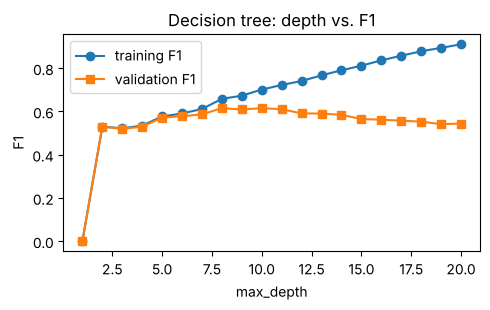

Depth with the highest validation F1: 8


In [18]:
# 5.1 Decision tree: training vs. validation F1 as max_depth grows (no minimum leaf size)
depths = list(range(1, 21))
tr_s, va_s = validation_curve(tree_pipe, X_train, y_train, param_name="clf__max_depth",
                              param_range=depths, cv=cv, scoring="f1", n_jobs=-1)
plt.figure(figsize=(5, 3.2))
plt.plot(depths, tr_s.mean(1), "o-", label="training F1")
plt.plot(depths, va_s.mean(1), "s-", label="validation F1")
plt.xlabel("max_depth"); plt.ylabel("F1"); plt.title("Decision tree: depth vs. F1"); plt.legend()
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/tree_depth_curve.png", dpi=200); plt.show()
print("Depth with the highest validation F1:", depths[int(va_s.mean(1).argmax())])

Training F1 keeps rising with depth while validation F1 peaks and then declines: the deeper tree overfits. Maximum depth and minimum leaf size are therefore used as **pre-pruning** stopping criteria and tuned below.

In [19]:
# 5.2 Decision tree grid search (2 x 8 x 4 x 2 = 128 combinations)
tree_grid = {
    "clf__criterion": ["gini", "entropy"],               # impurity measure
    "clf__max_depth": [4, 6, 8, 10, 12, 15, 20, None],   # pre-pruning: maximum depth (None = unlimited)
    "clf__min_samples_leaf": [1, 10, 30, 60],            # pre-pruning: minimum number of records per leaf
    "clf__class_weight": [None, "balanced"],             # class weighting: higher cost for errors on the minority class
}
t0 = time.time()
tree_search = GridSearchCV(tree_pipe, tree_grid, cv=cv, scoring=SCORING, refit=MAIN, n_jobs=-1)
tree_search.fit(X_train, y_train)
print(f"Time: {time.time() - t0:.1f} s")
print("Best parameters:", tree_search.best_params_)
print("Cross-validated F1:", round(tree_search.best_score_, 4))

Time: 119.4 s
Best parameters: {'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__min_samples_leaf': 60}
Cross-validated F1: 0.6413


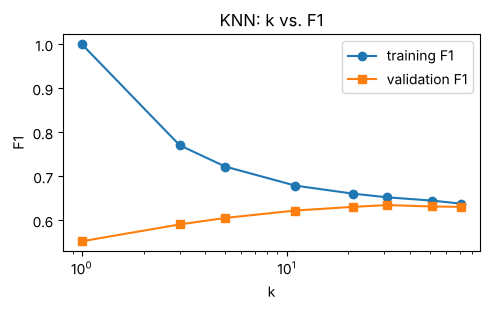

{1: np.float64(0.553), 3: np.float64(0.591), 5: np.float64(0.606), 11: np.float64(0.622), 21: np.float64(0.631), 31: np.float64(0.635), 51: np.float64(0.632), 71: np.float64(0.631)}


In [20]:
# 5.3 KNN: training vs. validation F1 as k grows (small k overfits, large k underfits)
ks = [1, 3, 5, 11, 21, 31, 51, 71]
tr_s, va_s = validation_curve(knn_pipe, X_train, y_train, param_name="clf__n_neighbors",
                              param_range=ks, cv=cv, scoring="f1", n_jobs=-1)
plt.figure(figsize=(5, 3.2))
plt.plot(ks, tr_s.mean(1), "o-", label="training F1")
plt.plot(ks, va_s.mean(1), "s-", label="validation F1")
plt.xscale("log"); plt.xlabel("k"); plt.ylabel("F1"); plt.title("KNN: k vs. F1"); plt.legend()
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/knn_k_curve.png", dpi=200); plt.show()
print({k: round(v, 3) for k, v in zip(ks, va_s.mean(1))})

At k = 1 the training F1 is 1.0 (each record is its own nearest neighbor) while validation F1 is much lower; as k grows the two converge and validation F1 levels off. KNN is a lazy learner with no iterative training, so it has no stopping criterion; its complexity is controlled by k.

In [21]:
# 5.4 KNN grid search (4 x 2 x 2 = 16 combinations; slow, because prediction needs distances to all training records)
knn_grid = {
    "clf__n_neighbors": [11, 21, 31, 51],
    "clf__weights": ["uniform", "distance"],   # majority vote vs. distance-weighted vote
    "clf__p": [1, 2],                          # Minkowski distance: r = 1 (Manhattan) or r = 2 (Euclidean)
}
t0 = time.time()
knn_search = GridSearchCV(knn_pipe, knn_grid, cv=cv, scoring=SCORING, refit=MAIN, n_jobs=-1)
knn_search.fit(X_train, y_train)
print(f"Time: {time.time() - t0:.1f} s")
print("Best parameters:", knn_search.best_params_)
print("Cross-validated F1:", round(knn_search.best_score_, 4))

Time: 288.7 s
Best parameters: {'clf__n_neighbors': 51, 'clf__p': 1, 'clf__weights': 'distance'}
Cross-validated F1: 0.6373


The selected k = 51 lies on the edge of the grid; since the validation curve has already flattened from k = 31, larger values are unlikely to bring much improvement.

In [22]:
# 5.5 Cross-validation results of the selected models (mean ± standard deviation)
def cv_summary(search, name):
    r = search.cv_results_; i = search.best_index_
    return {"model": name, **{f"cv_{m}": f"{r[f'mean_test_{m}'][i]:.4f} ± {r[f'std_test_{m}'][i]:.4f}" for m in SCORING}}
pd.DataFrame([cv_summary(tree_search, "Decision Tree"), cv_summary(knn_search, "KNN")])

,model,cv_f1,cv_auprc,cv_roc_auc,cv_accuracy
0,Decision Tree,0.6413 ± 0.0046,0.6747 ± 0.0086,0.8731 ± 0.0024,0.7770 ± 0.0055
1,KNN,0.6373 ± 0.0136,0.7049 ± 0.0164,0.8865 ± 0.0048,0.8368 ± 0.0041


## 6. Evaluation on the test set (used only once, here)

In [23]:
def evaluate(model, name):
    t0 = time.time(); model.fit(X_train, y_train); fit_t = time.time() - t0
    t0 = time.time(); prob = model.predict_proba(X_test)[:, 1]; pred = (prob >= 0.5).astype(int); pred_t = time.time() - t0
    return {"model": name,
            "accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred),
            "auprc": average_precision_score(y_test, prob), "roc_auc": roc_auc_score(y_test, prob),
            "fit_s": fit_t, "predict_s": pred_t}, prob, pred

best_tree, best_knn = tree_search.best_estimator_, knn_search.best_estimator_
res_tree, prob_tree, pred_tree = evaluate(best_tree, "Decision Tree")
res_knn,  prob_knn,  pred_knn  = evaluate(best_knn, "KNN")
baseline = {"model": "Baseline (all 'no')", "accuracy": 1 - y_test.mean(), "precision": 0, "recall": 0, "f1": 0,
            "auprc": y_test.mean(), "roc_auc": 0.5, "fit_s": 0, "predict_s": 0}
results = pd.DataFrame([baseline, res_tree, res_knn]).round(4)
results.to_csv(f"{FIG_DIR}/test_results.csv", index=False)
results

,model,accuracy,precision,recall,f1,auprc,roc_auc,fit_s,predict_s
0,Baseline (all 'no'),0.7624,0.0000,0.0000,0.0000,0.2376,0.5000,0.0000,0.0000
1,Decision Tree,0.7687,0.5082,0.8220,0.6281,0.6664,0.8717,0.3942,0.0261
2,KNN,0.8368,0.6749,0.6042,0.6376,0.6927,0.8851,0.0884,8.2865


Both models clearly beat the baseline on F1 and AUPRC, while the baseline's accuracy shows why accuracy alone is misleading. The fit and prediction times illustrate the difference between an eager learner (decision tree) and a lazy learner (KNN).

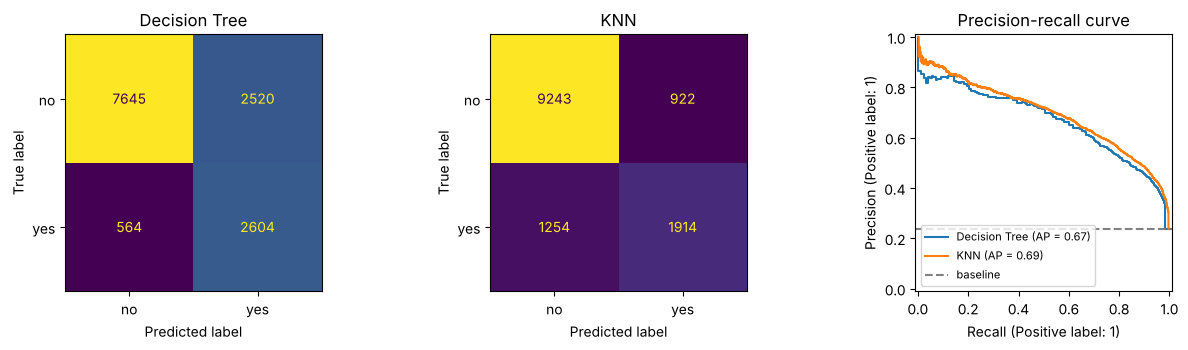

Decision Tree: TP=2604, FP=2520, FN=564, TN=7645
KNN: TP=1914, FP=922, FN=1254, TN=9243


In [24]:
# 6.2 Confusion matrices and precision-recall curves
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, pred, name in [(axes[0], pred_tree, "Decision Tree"), (axes[1], pred_knn, "KNN")]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["no", "yes"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
PrecisionRecallDisplay.from_predictions(y_test, prob_tree, name="Decision Tree", ax=axes[2])
PrecisionRecallDisplay.from_predictions(y_test, prob_knn, name="KNN", ax=axes[2])
axes[2].axhline(y_test.mean(), ls="--", c="gray", label="baseline"); axes[2].legend(fontsize=8)
axes[2].set_title("Precision-recall curve")
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/cm_pr.png", dpi=200); plt.show()
for name, pred in [("Decision Tree", pred_tree), ("KNN", pred_knn)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{name}: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

In [25]:
# 6.3 Decision tree feature importance (one-hot columns summed back to the original attributes)
prep = best_tree.named_steps["prep"]
names = prep.get_feature_names_out()
imp = pd.Series(best_tree.named_steps["clf"].feature_importances_, index=names)
orig = imp.groupby(lambda n: next(f for f in num_feats + cat_feats if n.split("__", 1)[1].startswith(f))).sum()
orig.sort_values(ascending=False).round(3)

weather_pattern      0.481
aptitude_score       0.243
performance_score    0.078
activity_duration    0.066
stability_index      0.034
personal_interest    0.029
load_ratio           0.022
index_weight         0.018
brew_preference      0.008
instrument           0.007
species              0.007
mineral_type         0.006
geological_era       0.001
region               0.000
perf_zero            0.000
dtype: float64

The tree relies mostly on `weather_pattern` and `aptitude_score`. `instrument` and `mineral_type`, which were strongly associated with the label in the EDA, receive little importance, because their information is largely captured by correlated attributes (Section 2.6): `mineral_type` by `aptitude_score`, and `instrument` partly by `weather_pattern`. `perf_zero` has zero importance for the tree, because a single threshold on `performance_score` already isolates those records.

## 7. Wrapper-style check: is `index_weight` irrelevant?

The tuned decision tree is cross-validated with and without `index_weight`, so the decision is based on model performance rather than intuition.

In [26]:
def cv_f1_without(pipe_builder, drop_cols, params):
    global num_feats
    saved = num_feats
    num_feats = [c for c in saved if c not in drop_cols]
    pipe = pipe_builder(); pipe.set_params(**params)
    s = cross_validate(pipe, X_train.drop(columns=drop_cols), y_train, cv=cv, scoring="f1", n_jobs=-1)["test_score"]
    num_feats = saved
    return s.mean(), s.std()

build_tree = lambda: Pipeline([("prep", make_preprocessor("tree")), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))])
print("Decision tree, with index_weight:   ", tree_search.best_score_.round(4))
print("Decision tree, without index_weight (mean, std):", np.round(cv_f1_without(build_tree, ["index_weight"], tree_search.best_params_), 4))

Decision tree, with index_weight:    0.6413


Decision tree, without index_weight (mean, std): [0.6402 0.0025]


Removing `index_weight` changes the cross-validated F1 only marginally, which supports the EDA finding that it is nearly irrelevant. Because the effect is negligible either way, it is kept.